In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from octvision3d.utils import get_filenames, create_directory
import tifffile as tiff
from tqdm import tqdm
import cv2
import os
import shutil

In [2]:
image_folder = "/home/mstudxk5/Desktop/OCTAVE_data/nnUNet_raw/external_tests/Rasti_nnUNet/imagesTs/"
label_folder = "/home/mstudxk5/Desktop/OCTAVE_data/nnUNet_raw/external_tests/Rasti_nnUNet/labelsTs/"
image_output = os.path.join(image_folder, "reshaped")
label_output = os.path.join(label_folder, "reshaped")
create_directory(image_output)
create_directory(label_output)

image_files = get_filenames(image_folder, ext="tif")
label_files = get_filenames(label_folder, ext="tif")
image_jsons = get_filenames(image_folder, ext="json")
label_jsons = get_filenames(label_folder, ext="json")
assert(len(image_files) > 0 and
       len(image_files) == len(label_files) == len(image_jsons) == len(label_jsons))

In [3]:
def reshape(image, target_height=496, target_width=1024, mode="bilinear"):
    """
    Reshape a 3D NumPy image volume by resizing height and width per slice.

    Parameters:
        image (np.ndarray): Input image array of shape (z, y, x).
        target_height (int): Desired height (y-dimension) of each slice.
        target_width (int): Desired width (x-dimension) of each slice.
        mode (str): Interpolation method: 'nearest', 'bilinear', or 'bicubic'.

    Returns:
        np.ndarray: Resized image array of shape (z, target_height, target_width).
    """
    if not isinstance(image, np.ndarray):
        raise TypeError("Input must be a NumPy array.")
    if image.ndim != 3:
        raise ValueError("Input image must be a 3D array of shape (z, y, x).")

    interpolation_modes = {
        "nearest": cv2.INTER_NEAREST,
        "bilinear": cv2.INTER_LINEAR,
        "bicubic": cv2.INTER_CUBIC
    }

    if mode not in interpolation_modes:
        raise ValueError(f"Unsupported mode '{mode}'. Choose from {list(interpolation_modes.keys())}.")

    z_dim = image.shape[0]
    resized_slices = []

    for z in range(z_dim):
        slice_2d = image[z].astype(np.uint8)
        resized = cv2.resize(
            slice_2d,
            (target_width, target_height),
            interpolation=interpolation_modes[mode]
        )
        resized_slices.append(resized)

    return np.stack(resized_slices, axis=0)  # shape: (z, target_height, target_width)

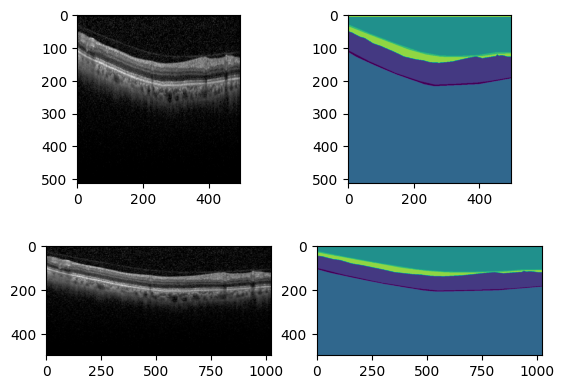

In [4]:
f, ax = plt.subplots(2, 2)
ax[0][0].imshow(tiff.imread(image_files[0])[0], cmap="gray")
ax[0][1].imshow(tiff.imread(label_files[0])[0])
ax[1][0].imshow(reshape(tiff.imread(image_files[0]))[0], cmap="gray")
ax[1][1].imshow(reshape(tiff.imread(label_files[0]))[0])

In [6]:
for image_f, label_f, image_j, label_j in tqdm(zip(image_files, label_files, image_jsons, label_jsons), total=len(image_files)):
    image = tiff.imread(image_f)
    label = tiff.imread(label_f)
    image_reshaped = reshape(image)
    label_reshaped = reshape(label)
    tiff.imwrite(os.path.join(image_output, os.path.basename(image_f)), image_reshaped.astype(np.uint8))
    tiff.imwrite(os.path.join(label_output, os.path.basename(label_f)), label_reshaped.astype(np.int64))
    shutil.copy(image_j, os.path.join(image_output, os.path.basename(image_j)))
    shutil.copy(label_j, os.path.join(label_output, os.path.basename(label_j)))
    

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 148/148 [00:18<00:00,  7.81it/s]
